In [ ]:
import pandas as pd
df = pd.read_csv('/content/Finance_Loan_Dataset.csv')

In [ ]:
print(df.shape)
print(df.head())

(1200, 33)
      ID  year  loan_limit  Gender approv_in_adv      loan_type loan_purpose  \
0  C1000  2021     1000000  Female            No      Auto Loan      Startup   
1  C1001  2022      900000    Male            No      Home Loan     Purchase   
2  C1002  2022      700000    Male            No  Personal Loan      Medical   
3  C1003  2022      700000  Female            No      Auto Loan     Purchase   
4  C1004  2022      800000  Female            No      Auto Loan      Startup   

  Credit_Worthiness open_credit business_or_commercial  ...  income  \
0              Good          No               Business  ...   56523   
1           Average          No               Personal  ...  194884   
2              Good          No               Personal  ...  119208   
3              Poor          No               Personal  ...   92281   
4           Average         Yes               Personal  ...   37896   

   credit_type  co-applicant_credit_type  age  submission_of_application  \
0    

In [ ]:
print(df.isnull().sum())

ID                             0
year                           0
loan_limit                     0
Gender                         0
approv_in_adv                  0
loan_type                      0
loan_purpose                   0
Credit_Worthiness              0
open_credit                    0
business_or_commercial         0
loan_amount                    0
rate_of_interest               0
Interest_rate_spread           0
Upfront_charges                0
term                           0
Neg_ammortization              0
interest_only                  0
lump_sum_payment               0
property_value                 0
construction_type            291
occupancy_type               404
Secured_by                   606
total_units                    0
income                         0
credit_type                    0
co-applicant_credit_type       0
age                            0
submission_of_application      0
LTV                            0
Region                         0
Security_T

In [ ]:
print(df.columns)

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'LTV', 'Region', 'Security_Type', 'status',
       'dtir1'],
      dtype='object')


In [ ]:
df=df.fillna(df.mode().iloc[0])

In [ ]:
print(df.isnull().sum())

ID                           0
year                         0
loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
Interest_rate_spread         0
Upfront_charges              0
term                         0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
income                       0
credit_type                  0
co-applicant_credit_type     0
age                          0
submission_of_application    0
LTV                          0
Region                       0
Security_Type                0
status                       0
dtir1   

In [ ]:
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)

IQR = Q3-Q1

lower_bound = Q1-1.5*IQR

upper_bound = Q3+1.5*IQR

outliers=df[
    (df['income']<lower_bound)|
    (df['income']>upper_bound)
]

print(outliers)


Empty DataFrame
Columns: [ID, year, loan_limit, Gender, approv_in_adv, loan_type, loan_purpose, Credit_Worthiness, open_credit, business_or_commercial, loan_amount, rate_of_interest, Interest_rate_spread, Upfront_charges, term, Neg_ammortization, interest_only, lump_sum_payment, property_value, construction_type, occupancy_type, Secured_by, total_units, income, credit_type, co-applicant_credit_type, age, submission_of_application, LTV, Region, Security_Type, status, dtir1]
Index: []

[0 rows x 33 columns]


In [ ]:
from scipy.stats import zscore

df['z_score'] = zscore(df['income'])

outliers = df[
    (df['z_score']>3)|
    (df['z_score']<-3)
]

print(outliers)

Empty DataFrame
Columns: [ID, year, loan_limit, Gender, approv_in_adv, loan_type, loan_purpose, Credit_Worthiness, open_credit, business_or_commercial, loan_amount, rate_of_interest, Interest_rate_spread, Upfront_charges, term, Neg_ammortization, interest_only, lump_sum_payment, property_value, construction_type, occupancy_type, Secured_by, total_units, income, credit_type, co-applicant_credit_type, age, submission_of_application, LTV, Region, Security_Type, status, dtir1, status_encoded, loan_type_encoded, income_normalized, loan_amount_normalized, risk_score, affordability_index, z_score]
Index: []

[0 rows x 40 columns]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

UNIVARIATE ANALYSIS

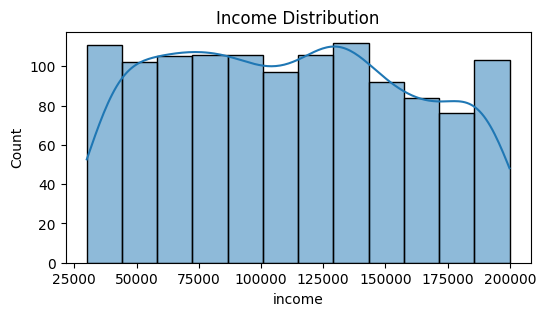

In [ ]:
plt.figure(figsize=(6,3))

sns.histplot(df['income'],kde=True)

plt.title('Income Distribution')
plt.show()

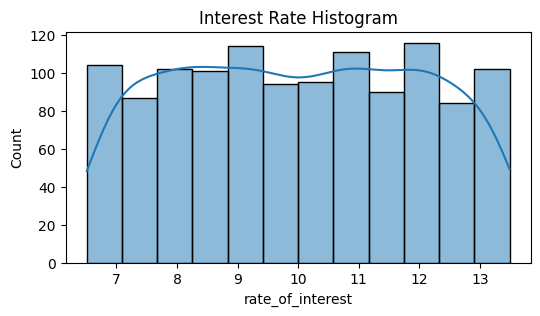

In [ ]:
plt.figure(figsize=(6,3))

sns.histplot(x=df['rate_of_interest'],kde=True)
plt.title("Interest Rate Histogram")

plt.show()

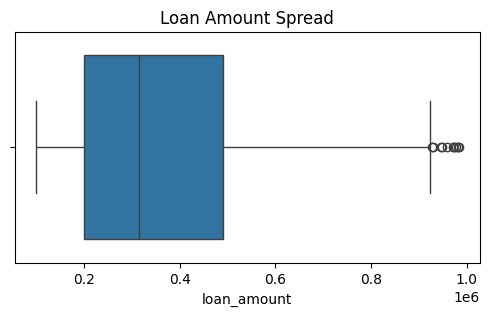

In [ ]:
plt.figure(figsize=(6,3))

sns.boxplot(x=df['loan_amount'])
plt.title("Loan Amount Spread")

plt.show()

BIVARIATE ANALYSIS

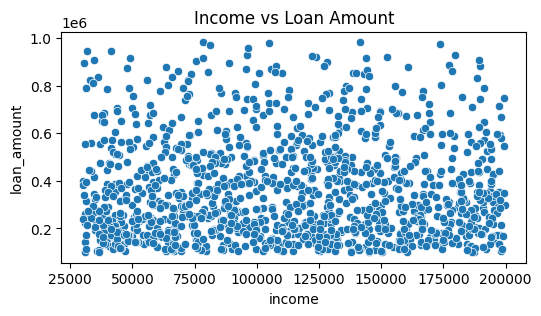

In [ ]:
plt.figure(figsize=(6,3))

sns.scatterplot(
    x=df['income'],
    y=df['loan_amount']
)

plt.title("Income vs Loan Amount")

plt.show()

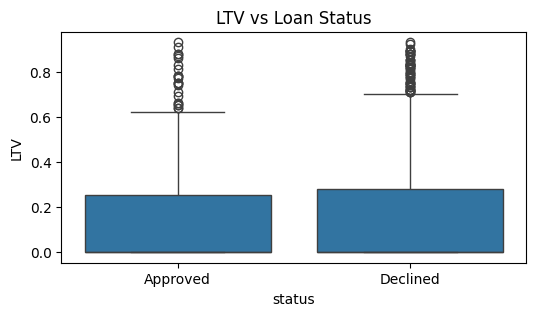

In [ ]:
plt.figure(figsize=(6,3))

sns.boxplot(
    x=df['status'],
    y=df['LTV']
)

plt.title("LTV vs Loan Status")
plt.show()

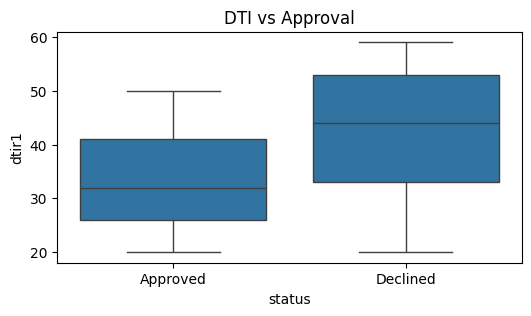

In [ ]:
plt.figure(figsize=(6,3))

sns.boxplot(
    x=df['status'],
    y=df['dtir1']
)

plt.title("DTI vs Approval")

plt.show()

MULTIVARIATE ANALYSIS

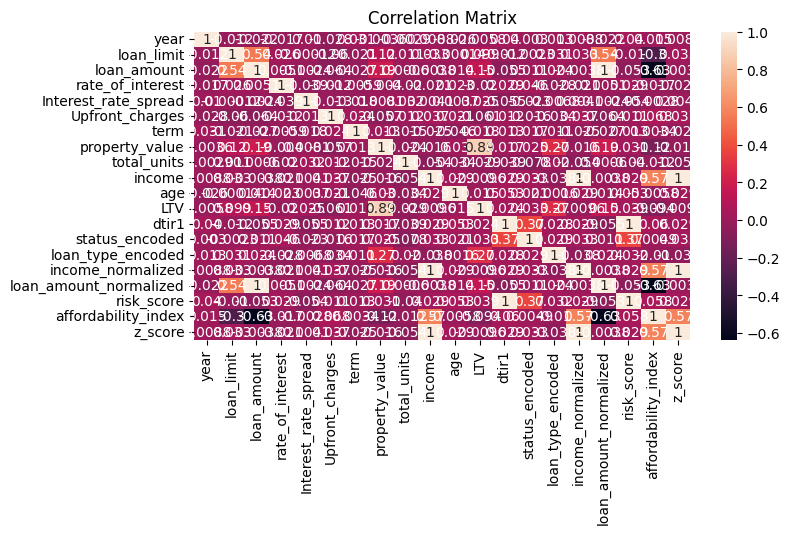

In [ ]:
plt.figure(figsize=(8,4))

corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

plt.title("Correlation Matrix")
plt.show()

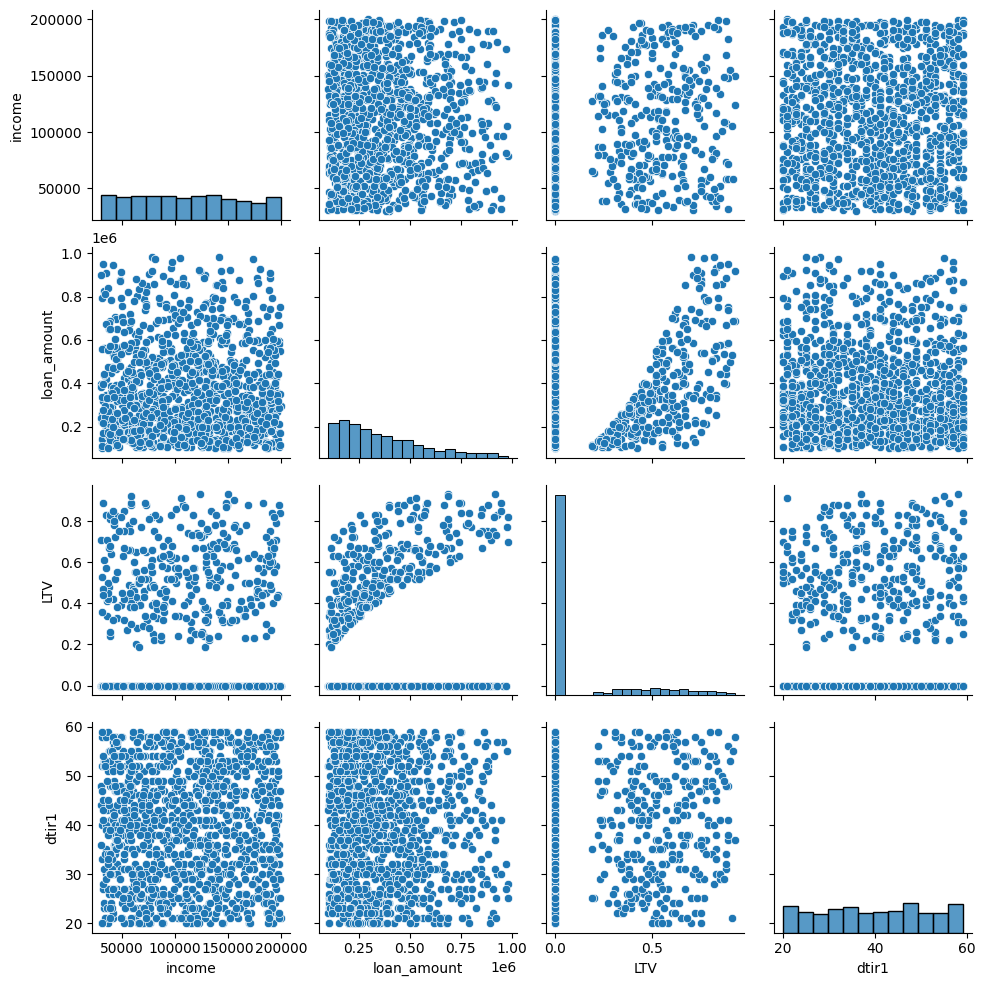

In [ ]:
sns.pairplot(
    df[
      ['income',
       'loan_amount',
       'LTV',
       'dtir1']
    ]
)

plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['status_encoded']=le.fit_transform(df['status'])
df['loan_type_encoded']=le.fit_transform(df['loan_type'])

In [ ]:
print(df.head())

      ID  year  loan_limit  Gender approv_in_adv      loan_type loan_purpose  \
0  C1000  2021     1000000  Female            No      Auto Loan      Startup   
1  C1001  2022      900000    Male            No      Home Loan     Purchase   
2  C1002  2022      700000    Male            No  Personal Loan      Medical   
3  C1003  2022      700000  Female            No      Auto Loan     Purchase   
4  C1004  2022      800000  Female            No      Auto Loan      Startup   

  Credit_Worthiness open_credit business_or_commercial  ...  Security_Type  \
0              Good          No               Business  ...        Secured   
1           Average          No               Personal  ...      Unsecured   
2              Good          No               Personal  ...        Secured   
3              Poor          No               Personal  ...        Secured   
4           Average         Yes               Personal  ...      Unsecured   

     status  dtir1  status_encoded  loan_type_enco

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [ ]:
df['income_normalized']=scaler.fit_transform(df[['income']])
print(df[['income','income_normalized']].head())

   income  income_normalized
0   56523           0.156105
1  194884           0.970477
2  119208           0.525059
3   92281           0.366571
4   37896           0.046469


In [ ]:
df['loan_amount_normalized']=scaler.fit_transform(df[['loan_amount']])
print(df[['loan_amount','loan_amount_normalized']].head())

   loan_amount  loan_amount_normalized
0       437086                0.381743
1       146466                0.052544
2       227403                0.144225
3       274737                0.197843
4       649623                0.622494


In [ ]:
df['risk_score']=(
    df['dtir1']*0.6+
    df['LTV']*0.4
)
print(df['risk_score'])

0       15.600
1       32.084
2       22.200
3       22.800
4       26.400
         ...  
1195    32.720
1196    15.000
1197    32.052
1198    18.600
1199    29.564
Name: risk_score, Length: 1200, dtype: float64


In [ ]:
df['affordability_index']=(
    df['income']/df['loan_amount']
)
print(df['affordability_index'])

0       0.129318
1       1.330575
2       0.524215
3       0.335889
4       0.058335
          ...   
1195    0.125119
1196    0.359578
1197    0.344990
1198    0.283563
1199    0.640109
Name: affordability_index, Length: 1200, dtype: float64


In [ ]:
df.to_csv("cleaned_finance_loan_dataset.csv",index=False)